## Installing uv

To start, you'll want to have uv installed:

https://docs.astral.sh/uv/getting-started/installation/


**Next, run this in the terminal, from the parent directory:**

    uv sync


Now you will have the kernel used to run this notebook

---

## Running the Required Servers

You need to run **three servers**, each in its own terminal:

- `central_server.py`
- `AS_server_SimAtomRes.py`
- `Ceos_server_twin.py`

### 1. Activate the Virtual Environment

`uv` should have created a `.venv` directory for you.

**On macOS / Linux:**

    source .venv/bin/activate

**On Windows (likely):**

    source .venv/Scripts/activate

You should now see the environment activated.

---

### 2. Start the Servers

**Terminal 1 — Central Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.protocols.central_server

**Terminal 2 — Atom Resolution Simulation Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.AS_server_SimAtomRes

**Terminal 3 — CEOS Twin Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.Ceos_server_twin

---

You're now ready to run this notebook! 🚀

In [74]:
import sys
import ast
sys.path.insert(0, '../')
from asyncroscopy.clients.notebook_client import NotebookClient
import matplotlib.pyplot as plt

import pyTEMlib
from pyTEMlib import probe_tools as pt

### Connections:

In [75]:
# Connect the Client to the central (async) server
tem = NotebookClient.connect(host='localhost',port=9000)

# Tell the central server address of all connected instruments
routing_table= {"AS": ("localhost", 9001),
                "Gatan": ("localhost", 9002),
                "Ceos": ("localhost", 9003),
                "Preacquired_AS": ("localhost", 9004)}
tem.send_command('Central',"set_routing_table", routing_table)

# ConnectionResetError: [Errno 54] Connection reset by peer 
# in terminal, type:
# lsof -i :9000

Connecting to central server localhost:9000...
Connected to central server.


'[Central] Routing table updated'

In [76]:
# connect to the AutoScript computer and initialize microscope
tem.send_command('AS',command='connect_AS',args={'host':'10.46.217.241','port':9095})

'[AS] Connected to microscope.'

In [77]:
tem.send_command(destination = 'Ceos', command = 'getInfo', args = {})

'412:{"jsonrpc": "2.0", "result": {"host": "198.211.143.10", "mode": "STEM", "version": "v1.6-221-gbb906f58", "kernelProtocolVersion": [1, 12, 4], "currentSetting": "MC_STEM@200KV", "currentLabel": "calibrated", "measurementRange": {"We": 1.8609205752267538e-07, "A2": 4.038456289966122e-06, "B2": 2.019228144983061e-06}, "correctorType": "DCORPRIME", "kernelVersion": "5-6-373", "kernelHexVersion": 329589}, "id": 1},'

### Help commands:

In [8]:
# Now that we're routed to all instruments,
# let's take an inventory of commands available on each instrument
cmds = tem.send_command('AS', 'discover_commands')
print(cmds)

["blank_beam", "calibrate_screen_current", "connect_AS", "connectionLost", "connectionMade", "dataReceived", "disconnect", "discover_commands", "get_help", "get_scanned_image", "get_stage", "get_status", "lengthLimitExceeded", "logPrefix", "makeConnection", "pauseProducing", "place_beam", "resumeProducing", "sendString", "set_current", "stopProducing", "stringReceived", "unblank_beam"]


In [11]:
# These two are working, but should be much better.
tem.send_command('AS', command='get_help', args={'command_name':'connect_AS'})

'{"name": "connect_AS", "signature": "(args: dict)", "summary": "Connect to the microscope via AutoScript", "doc": "Connect to the microscope via AutoScript"}'

### Setting the aberrations from known values:

In [81]:
tableau_result_12  = tem.send_command(destination = 'Ceos', command = 'acquireTableau', args = {'tabType':"Fast", 'angle':1})


In [82]:
tableau_result_12

'459:{"jsonrpc": "2.0", "result": {"aberrations": {"A1": [1.5559003540146397e-10, 2.479548412635324e-09], "A2": [9.444008340385544e-08, 2.6602627842810495e-08], "B2": [-8.400185395564969e-08, -3.6928631237203514e-08], "C1": [2.829925369315607e-08, 0.0], "WD": [-0.0006556865821554961, 1.6668042656166153e-05]}, "confidence": {"A1": 1.417077506694724e-09, "A2": 4.7146201017438495e-08, "B2": 4.696829018248203e-08, "C1": 7.085387533473618e-10, "WD": NaN}}, "id": 1},'

In [83]:
import json
# Split at the first colon, take the second part, drop the trailing comma, and parse
data = json.loads(tableau_result_12.split(':', 1)[1][:-1])
# Extract the specific dictionary you want
aberrations = data['result']['aberrations']
print(aberrations)

{'A1': [1.5559003540146397e-10, 2.479548412635324e-09], 'A2': [9.444008340385544e-08, 2.6602627842810495e-08], 'B2': [-8.400185395564969e-08, -3.6928631237203514e-08], 'C1': [2.829925369315607e-08, 0.0], 'WD': [-0.0006556865821554961, 1.6668042656166153e-05]}


In [ ]:
# make each element 0
aberrations_deltas = 

In [ ]:
# import numpy as np
# def carth2polar(z):
#     return np.linalg.norm(z), np.degrees(np.arctan2(z[1], z[0]))

# tableau_result_12 = data['result']

# for key in ["C1", "A1", "B2", "A2"]:
#     amplitude, angle = carth2polar(tableau_result_12["aberrations"][key])
#     print(f" {key}: {amplitude * 1e9:.2f}nm {angle:.2f}deg")
# print(f" WD: {np.linalg.norm(tableau_result_12['aberrations']['WD']) * 1e3:.3f}mrad ")

 C1: 28.30nm 0.00deg
 A1: 2.48nm 86.41deg
 B2: 91.76nm -156.27deg
 A2: 98.12nm 15.73deg
 WD: 0.656mrad 


In [ ]:
param_ranges = {
    'C10': (-50e-9, 50e-9),    # defocus
    'C12a': (-10, 10), # twofold astigmatism (a)
    'C12b': (-10, 10)  # twofold astigmatism (b)
}

# B2 : 500nm, S3 : 5000nm

In [ ]:
def single_meas(val):
    tem.send_command(destination = 'Ceos', command = 'correctAberration', args = {'name':"A1", 'value':(val, 0*-10e-9), 'select': "coarse" })
    measure = 0
    tem.send_command(destination = 'Ceos', command = 'correctAberration', args = {'name':"A1", 'value':(-val, 0*-10e-9), 'select': "coarse" })
    return measure

tem.send_command(destination = 'Ceos', command = 'correctAberration', args = {'name':"A1", 'value':(50e-9, 0*-10e-9), 'select': "coarse" })

'182:{"jsonrpc": "2.0", "error": {"code": -32000, "message": "Server error", "data": {"type": "<class \'ValueError\'>", "message": "could not convert string to float: \'(5e-08,\'"}}, "id": 1},'

In [93]:
tem.send_command(destination = 'Ceos', command = 'correctAberration', args = {'name':"C1", 'value':-25e-9, 'select': "coarse" })

'43:{"jsonrpc": "2.0", "result": null, "id": 1},'

In [44]:
# args = {'name':"A1", 'value':(0*50e-9, 0*-10e-9), 'target': , 'select': "coarse" }


In [32]:
# at any time, we can view the current aberrations
# this should be implemented in the real ceos server as well


### Get an image:

simulated with pystemsim inside the AS_server_SimAtomRes (working with the Ceos server)

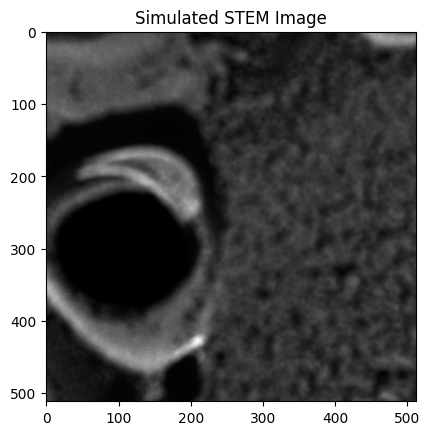

In [33]:
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.imshow(img, cmap="gray")
plt.title("Simulated STEM Image")
plt.show()


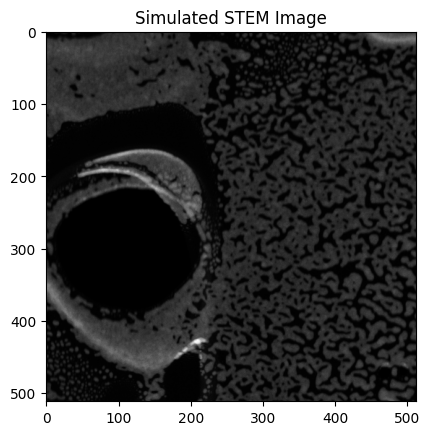

In [26]:
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.imshow(img, cmap="gray")
plt.title("Simulated STEM Image")
plt.show()


### How it's actually working:
![Structure Diagram](../DT_workflow.png)

### try changing an aberration

In [ ]:
tem.send_command(destination = 'Ceos', command = 'correctAberration', args = {"name": 'C10', "value": -6})

In [ ]:
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.imshow(img, cmap="gray")
plt.title("Simulated STEM Image")
plt.show()